# Discount Model

### 1. The Dataset
From 1989 to 1994, Chicago Booth and Dominick's Finer Foods entered into a partnership for store-level research into shelf management and pricing. Randomized experiments were conducted in more than 25 different categories throughout all stores in this 100-store chain. As a byproduct of this research cooperation, approximately nine years of store-level data on the sales of more than 3,500 UPCs is available in this database. This data is unique for the breadth of its coverage and for the information available on retail margins.


### 2. Columns Explanation

* `MOVE` -> Number of units sold that day/week (Target).
* `SALE`:
    * B = Bonus Purchase (Prime Purchase)
    * C = Coupon
    * S = Sale (Simple Sale)
    * (Empty) = No promotion.

* `PRICE` -> Exact amount paid by the customer at the register (including the promotion!!).
* `PROFIT` -> Profit Percentage! How much the store keeps.

**Useful columns for Cannibalization/Halo analysis**
* `UPC` -> Product Code
* `STORE` -> Location
* `WEEK` -> Time

In [178]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

def load_data(file_path):
    """Load data from a CSV file"""
    return pd.read_csv(file_path, encoding = 'latin1')

data = load_data('softDrinks.csv')
print(data.shape)
data.head(3)

(17476933, 14)


,UPC,STORE,WEEK,MOVE,QTY,PRICE,SALE,PROFIT,OK,COM_CODE,DESCRIP,SIZE,CASE,NITEM
0,179.0,2,1,1,1,10.0,NaN,99.9,1,225,BLOOD GLUCOSE SCREEN,EACH,1,9990290
1,179.0,2,2,0,1,0.0,NaN,0.0,1,225,BLOOD GLUCOSE SCREEN,EACH,1,9990290
2,179.0,2,3,0,1,0.0,NaN,0.0,1,225,BLOOD GLUCOSE SCREEN,EACH,1,9990290


### Cleaning Data

In [179]:
# Keep only rows where OK is 1
try:
    data = data[data.OK == 1]            
    data = data.drop(columns = ['OK', 'NITEM', 'CASE'], axis = 1)
    print('Columns deleted.')
except:
    print("Columns still deleted or doesn't exist.")

data.head(3)

Columns deleted.


,UPC,STORE,WEEK,MOVE,QTY,PRICE,SALE,PROFIT,COM_CODE,DESCRIP,SIZE
0,179.0,2,1,1,1,10.0,NaN,99.9,225,BLOOD GLUCOSE SCREEN,EACH
1,179.0,2,2,0,1,0.0,NaN,0.0,225,BLOOD GLUCOSE SCREEN,EACH
2,179.0,2,3,0,1,0.0,NaN,0.0,225,BLOOD GLUCOSE SCREEN,EACH


In [180]:
# Data without promotion
data_no_prom = data[data.SALE.isna()]
print(f'Data no promotion shape: {data_no_prom.shape}')

# Data with simple promotion
data_prom = data[data.SALE == 'S']
print(f'Data simple promotion shape: {data_prom.shape}')
data_prom.head(3)

Data no promotion shape: (14053282, 11)
Data simple promotion shape: (1660917, 11)


,UPC,STORE,WEEK,MOVE,QTY,PRICE,SALE,PROFIT,COM_CODE,DESCRIP,SIZE
5836,418.0,71,306,3,1,6.99,S,10.58,235,~DIET CRYSTAL PEPSI,24/12O
5865,418.0,71,300,4,1,5.99,S,-4.34,235,~DIET CRYSTAL PEPSI,24/12O
5922,418.0,107,348,1,1,5.99,S,-21.03,235,~DIET CRYSTAL PEPSI,24/12O


### Testing One Product -- Keep the highter intersect product between regular & prom 

In [181]:
# Keep Relevant Columns
data_no_prom = data_no_prom[['UPC', 'STORE', 'WEEK', 'PRICE', 'MOVE']]
data_prom = data_prom[['UPC', 'STORE', 'WEEK', 'PRICE', 'MOVE']]

# Check on specific product (the higther) & Specific Store
data_no_prom = data_no_prom[(data_no_prom.UPC == data_prom.UPC.value_counts().index[0]) & (data_no_prom.STORE == 2)]
data_prom = data_prom[(data_prom.UPC == data_prom.UPC.value_counts().index[0]) & (data_prom.STORE == 2)]

# Add column promotion or Not
data_no_prom['Promotion'] = 0
data_prom['Promotion'] = 1

# Concat & Order weeks
data_concat = pd.concat((data_no_prom, data_prom)).sort_values(by = 'WEEK', ascending = True).reset_index(drop = True)
print(data_concat.shape)
data_concat.tail()

(311, 6)


,UPC,STORE,WEEK,PRICE,MOVE,Promotion
306,1.200000e+09,2,392,1.69,129,0
307,1.200000e+09,2,396,1.69,41,0
308,1.200000e+09,2,397,1.09,78,1
309,1.200000e+09,2,398,1.67,40,0
310,1.200000e+09,2,399,1.69,46,0


### 1. Create Discount column

`Discount -> np.ceil((((t -1) - t) / (t - 1)) * 100)`

In [182]:
# Shift all by 1
data_concat['Price_Prev'] = data_concat.groupby(['UPC', 'STORE'])['PRICE'].shift(1)

# Discount -> # np.ceil((((t -1) - t) / (t - 1)) * 100)
data_concat['Discount'] = np.where(data_concat['Promotion'] == 1, ((data_concat['Price_Prev'] - data_concat['PRICE']) / data_concat['Price_Prev']) * 100, 0)
data_concat['Discount'] = np.where(data_concat['Discount'] < 0, 0, data_concat['Discount'])

print(data_concat.shape)
data_concat.tail()

(311, 8)


,UPC,STORE,WEEK,PRICE,MOVE,Promotion,Price_Prev,Discount
306,1.200000e+09,2,392,1.69,129,0,1.69,0.000000
307,1.200000e+09,2,396,1.69,41,0,1.69,0.000000
308,1.200000e+09,2,397,1.09,78,1,1.69,35.502959
309,1.200000e+09,2,398,1.67,40,0,1.09,0.000000
310,1.200000e+09,2,399,1.69,46,0,1.67,0.000000


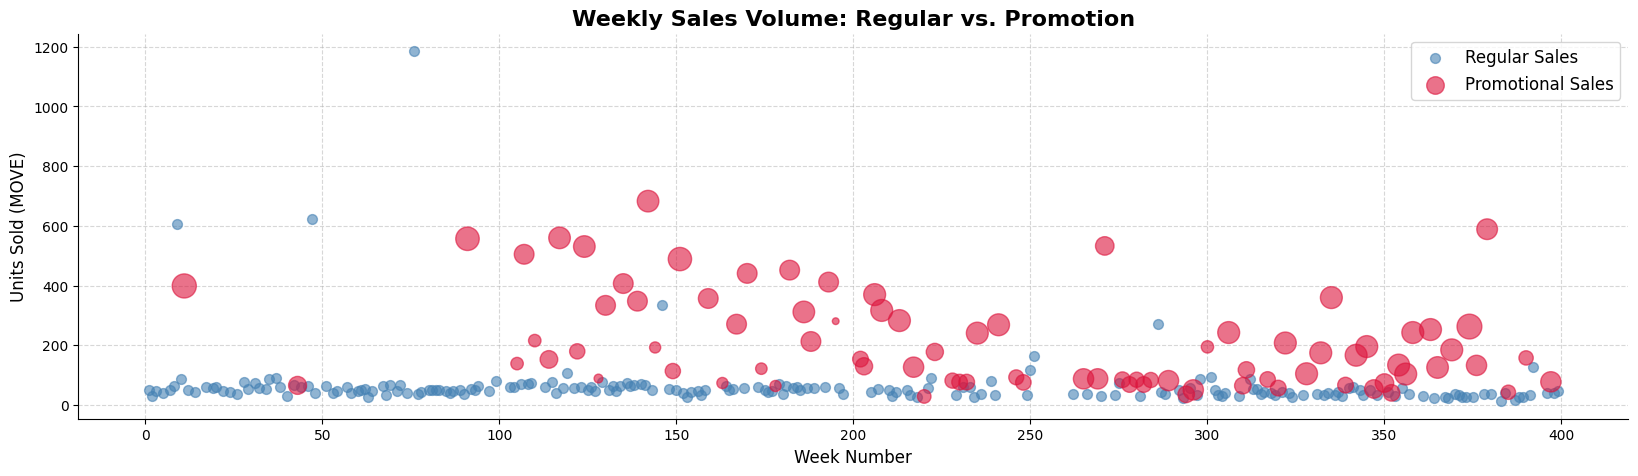

In [206]:
plt.figure(figsize = (20, 5))
plt.scatter(data_concat[data_concat.Promotion == 0].WEEK, data_concat[data_concat.Promotion == 0].MOVE, label = 'Regular Sales', color = 'steelblue', alpha = 0.6, s = 50)
plt.scatter(data_concat[data_concat.Promotion == 1].WEEK, data_concat[data_concat.Promotion == 1].MOVE, label = 'Promotional Sales',
             color = 'crimson', alpha = 0.6, s = data_concat[data_concat.Promotion == 1].Discount * 6)
plt.title('Weekly Sales Volume: Regular vs. Promotion', fontsize=16, fontweight='bold')
plt.xlabel('Week Number', fontsize = 12)
plt.ylabel('Units Sold (MOVE)', fontsize = 12)
plt.legend(fontsize = 12)
plt.grid(True, linestyle='--', alpha = 0.5)
plt.show()

### First Impressions
* Without a sale, a stable sales level is observed, which is an approximation of the basic demand.
* During sale periods, a significant positive deviation from the basic demand is observed, depending on the intensity of the sale.
* Weeks with a sale are colored red, with the size of the circle being in proportion to the size of the sale.
* Outliers that do not represent current demand were identified and removed for the purpose of estimating a baseline without bias.

## 2. Create Baseline

In [184]:
data_modelling = data_concat[data_concat.Promotion == 0][['WEEK', 'PRICE', 'MOVE']]
print(data_modelling.shape)
data_modelling.head(3)

(205, 3)


,WEEK,PRICE,MOVE
0,1,1.79,50
1,2,1.79,32
2,3,1.79,48


### 2.1 Detect Outliers using IQR Method

To prevent distortion in the baseline estimate due to outlier observations, and to ensure a faithful representation of the demand pattern, extreme values ​​were removed using the IQR statistical method.

* **Interquartile Range (IQR):**
    $$IQR = Q_3 - Q_1$$

* **Lower Control Limit (LCL) :**
    $$\text{Lower Bound} = Q_1 - 1.5 \times IQR$$

* **Upper Control Limit (UCL):**
    $$\text{Upper Bound} = Q_3 + 1.5 \times IQR$$

In [ ]:
def iqr(column:str, k:float = 1.5) -> float:
    '''
    Detect Outliers using IQR method
    Arg:
        column: str -> column name 
        k: float -> Scale Factor
    Return:
        lower: float -> LCL
        upper: float -> UCL

    '''
    # IQR Test
    Q1 = data_modelling[column].quantile(0.25)
    Q3 = data_modelling[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - k * IQR
    upper = Q3 + k * IQR

    print(f'Upper: {upper}')
    print(f'Lower: {lower}')

    return lower, upper

Upper: 109.0
Lower: -11.0


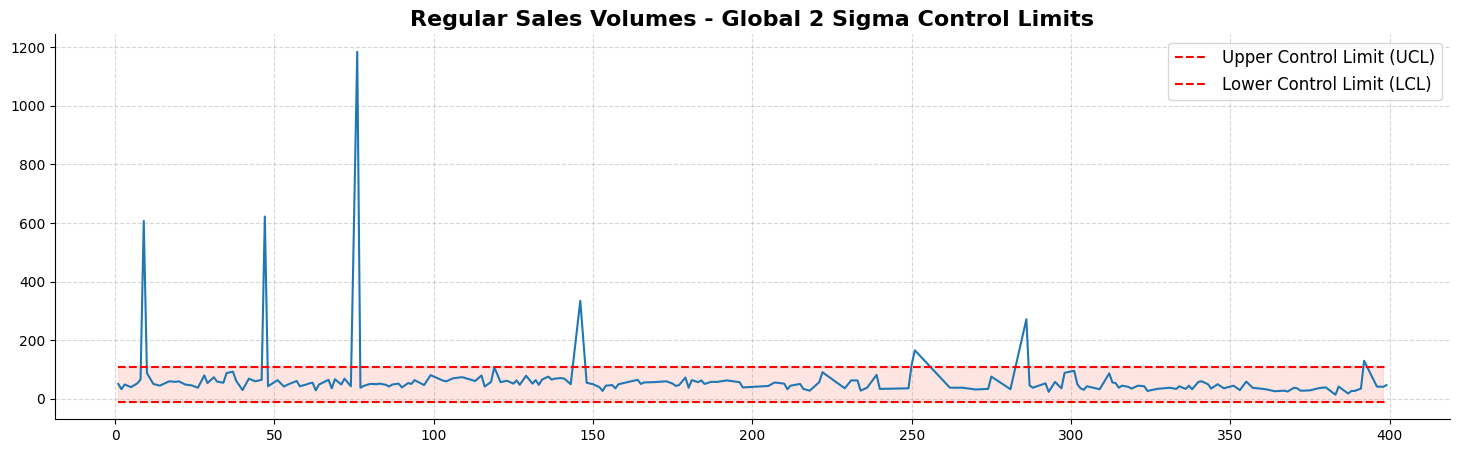

In [186]:
lower, upper = iqr(column = 'MOVE', k = 2)

plt.figure(figsize = (18, 5))
plt.plot(data_modelling.WEEK, data_modelling.MOVE)
plt.hlines(y = upper, xmin = np.min(data_modelling.WEEK), xmax = np.max(data_modelling.WEEK), linestyles = '--', colors = 'red', label = 'Upper Control Limit (UCL)')
plt.hlines(y = lower, xmin = np.min(data_modelling.WEEK), xmax = np.max(data_modelling.WEEK), linestyles = '--', colors = 'red', label = 'Lower Control Limit (LCL)')
plt.title('Regular Sales Volumes - Global 2 Sigma Control Limits', fontsize = 16, fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, ls = '--', alpha = 0.5)
plt.fill_between(x = range(np.min(data_modelling.WEEK), np.max(data_modelling.WEEK)), y1 = lower, y2 = upper, color = 'salmon', alpha = 0.2)
plt.legend(fontsize = 12)
plt.show()

### 2.2 Interpolation of new NaN values

In [187]:
# Dropping higthers points
data_modelling['MOVE'] = data_modelling['MOVE'].where(data_modelling['MOVE'] < upper)

# Interpolate
data_modelling['MOVE'] = data_modelling.MOVE.interpolate(method = 'linear')
data_modelling.tail()

,WEEK,PRICE,MOVE
305,391,1.69,34.0
306,392,1.69,37.5
307,396,1.69,41.0
309,398,1.67,40.0
310,399,1.69,46.0


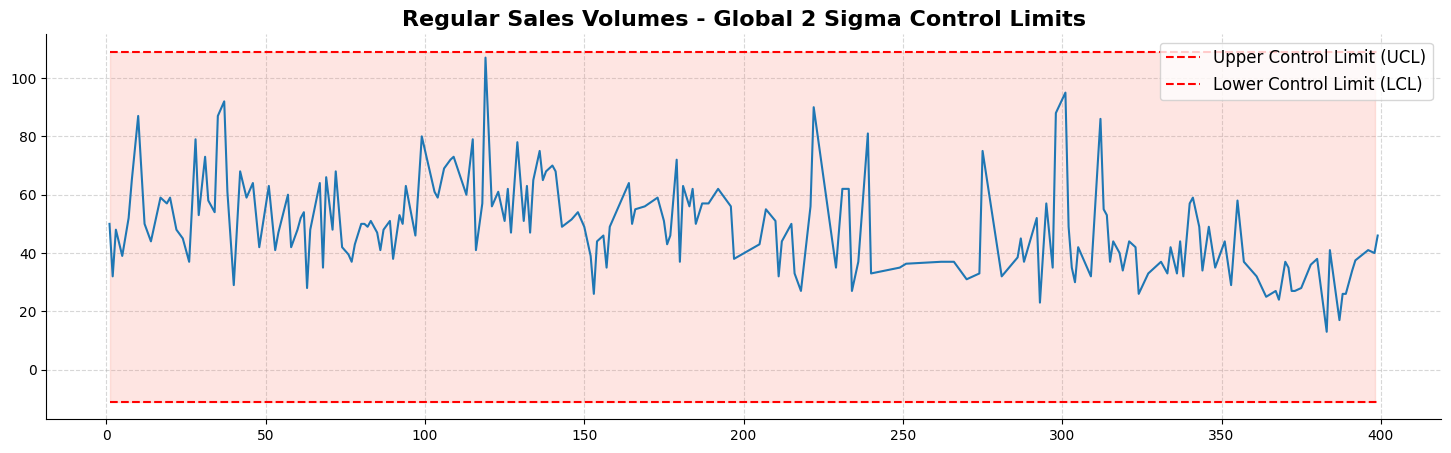

In [188]:
plt.figure(figsize = (18, 5))
plt.plot(data_modelling.WEEK, data_modelling.MOVE)
plt.hlines(y = upper, xmin = np.min(data_modelling.WEEK), xmax = np.max(data_modelling.WEEK), linestyles = '--', colors = 'red', label = 'Upper Control Limit (UCL)')
plt.hlines(y = lower, xmin = np.min(data_modelling.WEEK), xmax = np.max(data_modelling.WEEK), linestyles = '--', colors = 'red', label = 'Lower Control Limit (LCL)')
plt.title('Regular Sales Volumes - Global 2 Sigma Control Limits', fontsize = 16, fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, ls = '--', alpha = 0.5)
plt.fill_between(x = range(np.min(data_modelling.WEEK), np.max(data_modelling.WEEK)), y1 = lower, y2 = upper, color = 'salmon', alpha = 0.2)
plt.legend(fontsize = 12, loc = 'upper right')
plt.show()

### 2.3 First Algorithm - Simple Mooving Average (SMA)


The **Simple Moving Average (SMA)** is a technique in time series analysis used to smooth out short-term fluctuations and highlight underlying trends. It operates by calculating the unweighted mean of a specified number of the most recent data points.

#### Mathematical Formula
Given a time series and a fixed window size $n$ (also known as the rolling window), the moving average at time $t$ is calculated as the sum of the last $n$ values divided by $n$:

$$SMA_t = \frac{1}{n} \sum_{i=0}^{n-1} x_{t-i}$$

Where:
* $x_{t-i}$ represents the data points within the current window.
* $n$ is the size of the moving window (the span).

**Important :** A larger window size ($n$) results in a smoother curve but introduces a greater lag relative to the original data, whereas a smaller window is more responsive to recent changes but less effective at noise reduction.

In [189]:
def mooving_average(series, window_size):
    forecast = []
    for i in range(window_size, len(series)):                        #  2 -> 201       
        forecast.append(series[i - window_size : i].mean())           # data_modelling.MOVE[0: 2].mean() -> week 3
    forecast = np.array(forecast)
    return forecast

WINDOW_SIZE = 8
mooving_avg = mooving_average(series = data_modelling['MOVE'], window_size = WINDOW_SIZE)

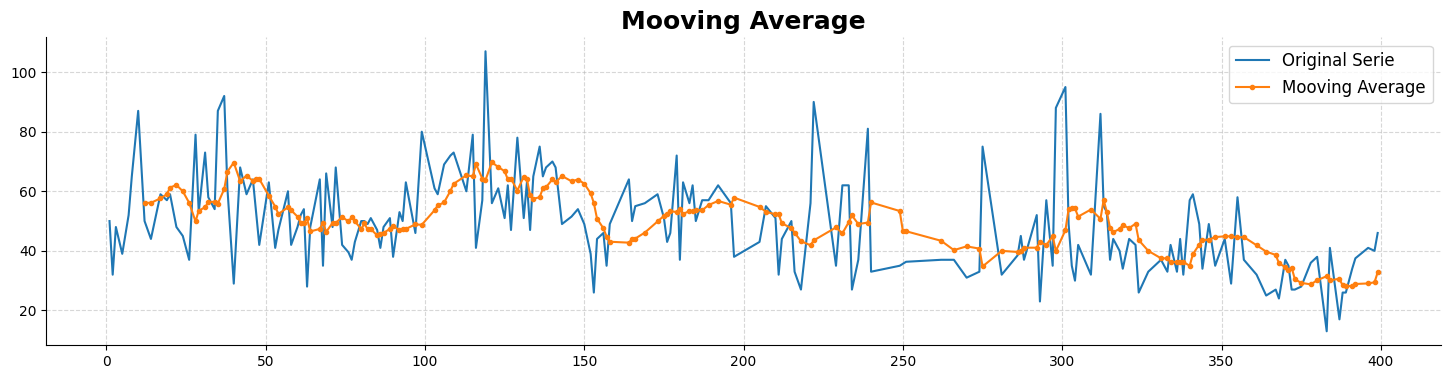

In [190]:
plt.figure(figsize = (18, 4))
plt.plot(data_modelling.WEEK, data_modelling.MOVE, label = 'Original Serie')
plt.plot(data_modelling.WEEK[WINDOW_SIZE:], mooving_avg, label = 'Mooving Average', marker = '.')
plt.title('Mooving Average', fontsize = 18, fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, ls = '--', alpha = 0.5)
plt.legend(fontsize = 12)
plt.show()

In [191]:
# Check metric (MAE)
from sklearn.metrics import mean_absolute_error, mean_squared_error

MAE = mean_absolute_error(y_true = data_modelling.MOVE[WINDOW_SIZE:], y_pred = mooving_avg)
print(MAE)

11.091899323181051


In [192]:
# Prediction Exemple - WEEK 400
prediction = data_modelling.tail(WINDOW_SIZE).MOVE.sum() / WINDOW_SIZE

# Confidence Intervale 
lower = prediction - MAE
upper = prediction + MAE

print(f'The prediction of sales for week 400 is: {prediction:.2f}.\nTypical Error Range: [{lower:.2f}, {upper:.2f}]')

The prediction of sales for week 400 is: 33.44.
Typical Error Range: [22.35, 44.53]


### 2.4 Second Algorithm - Exponential Weighted Moving Average (EWM)

The **Exponential Weighted Moving Average (EWM)** is an improvement over the simple moving average that applies weighting factors which decrease exponentially. Unlike the SMA, which weighs past observations equally, **EWM assigns greater importance to more recent data points**, making it more responsive to new information and trends.

The EWM is calculated recursively. For a series $x_t$, the value $y_t$ is defined as:

$$y_t = \alpha x_t + (1 - \alpha) y_{t-1}$$

Where:
* $x_t$ is the input value at time $t$.
* $y_{t-1}$ is the previous EWM value.
* $\alpha$ is the smoothing factor ($0 < \alpha \leq 1$).

**Important:** The parameter $\alpha$ determines the "memory" of the model. A higher $\alpha$ discounts older observations faster (closer to the current data), while a lower $\alpha$ produces a smoother curve. In pandas, this is often expressed via `span`, where $\alpha = 2 / (span + 1)$.

In [193]:
# apply EWM model
EWM = data_modelling['MOVE'].ewm(span = 52).mean()

### 2.5 Third Algorithm - Hodrick-Prescott Filter (HP Filter)

The **Hodrick-Prescott (HP) Filter** is a data smoothing technique widely used in macroeconomics. It separates a time series $y_t$ into two distinct components: a growth trend ($\tau_t$) and a cyclical component ($c_t$). The filter effectively removes short-term fluctuations to reveal the long-term trend.

The filter isolates the trend $\tau_t$ by minimizing the following loss function:

$$\min_{\tau} \left( \sum_{t=1}^T (y_t - \tau_t)^2 + \lambda \sum_{t=2}^{T-1} [(\tau_{t+1} - \tau_t) - (\tau_t - \tau_{t-1})]^2 \right)$$

Where:
* The first term penalizes the cyclical component (deviations from the trend).
* The second term penalizes variations in the growth rate of the trend.
* $\lambda$ (Lambda) is the smoothing parameter.

**Important:** The value of $\lambda$ controls the smoothness of the trend. Standard values are 1600 for quarterly data, 6.25 for annual data, and 14400 for monthly data.

In [194]:
from statsmodels.tsa.filters.hp_filter import hpfilter

cycle, trend_hp = hpfilter(x = data_modelling.MOVE, lamb = 14400)

### 2.6 Fouth Algorithm - STL Decomposition (Seasonal-Trend using LOESS)

**STL (Seasonal and Trend decomposition using Loess)** is a robust and versatile method for decomposing time series. Unlike classical decomposition methods, STL handles any type of seasonality (not just fixed periods) and is resilient to outliers. It uses LOESS (Locally Estimated Scatterplot Smoothing) to estimate the non-linear relationships.

#### Decomposition Structure
STL decomposes the time series $Y_t$ into three additive components:

$$Y_t = T_t + S_t + R_t$$

Where:
* $T_t$ is the **Trend** component (long-term progression).
* $S_t$ is the **Seasonal** component (repeating patterns).
* $R_t$ is the **Residual** (or Remainder) component (noise).

**Important:** STL allows the seasonal component to change over time (e.g., amplitude increasing) and provides control over the smoothness of the trend and seasonal cycles independently.

In [195]:
from statsmodels.tsa.seasonal import STL

stl = STL(endog = data_modelling.MOVE, period = 52)
res = stl.fit()
trend_stl = res.trend

### 2.7 Plotting all methods & finding lower MAE

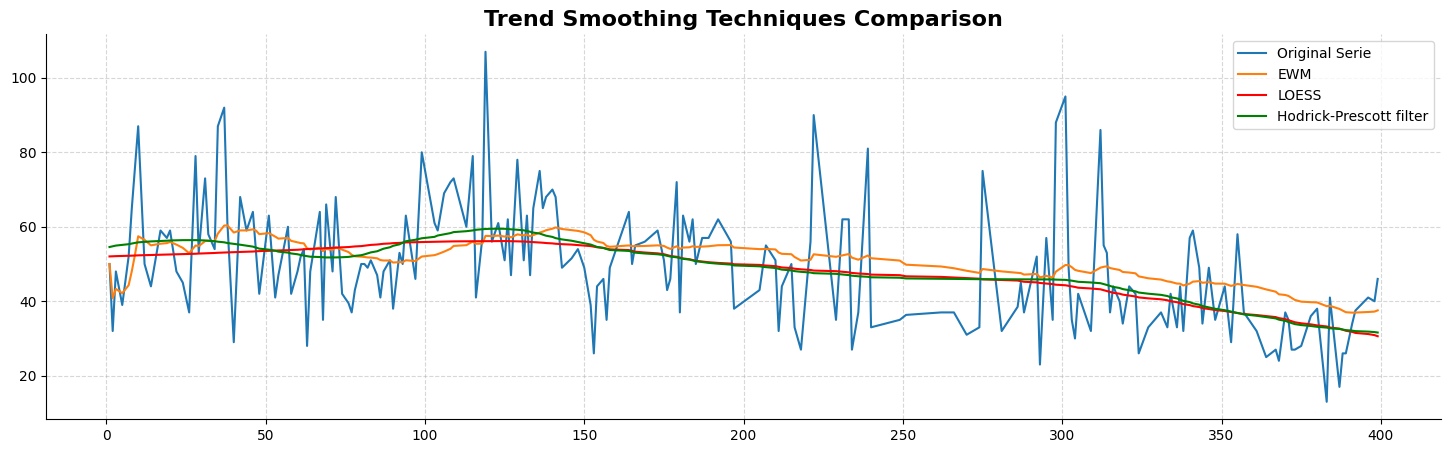

In [196]:
plt.figure(figsize = (18, 5))
plt.plot(data_modelling.WEEK, data_modelling.MOVE, label = 'Original Serie')
plt.plot(data_modelling.WEEK, EWM, label = 'EWM')
plt.plot(data_modelling.WEEK, trend_stl, label = 'LOESS', color = 'red')
plt.plot(data_modelling.WEEK, trend_hp, label = 'Hodrick-Prescott filter', color = 'green')
plt.title('Trend Smoothing Techniques Comparison', fontsize = 16, fontweight = 'bold')
plt.grid(True, ls = '--', alpha = 0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.show()

### 2.8 Checking lower MAE

In [197]:
# MAE 
mae_ewm = (data_modelling['MOVE'] - EWM).abs().mean()
mae_stl = (data_modelling['MOVE'] - trend_stl).abs().mean()
mae_hp  = (data_modelling['MOVE'] - trend_hp).abs().mean()

print(f"MAE EWM (Exponentially Weighted Moving Average) : {mae_ewm:.4f}")
print(f"MAE STL (LOESS)              : {mae_stl:.4f}")
print(f"MAE HP  (Hodrick-Prescott)   : {mae_hp:.4f}")

MAE EWM (Exponentially Weighted Moving Average) : 10.9327
MAE STL (LOESS)              : 10.7953
MAE HP  (Hodrick-Prescott)   : 10.5149


## 3. Create Price Baseline

### 3.1 Check Price Variability

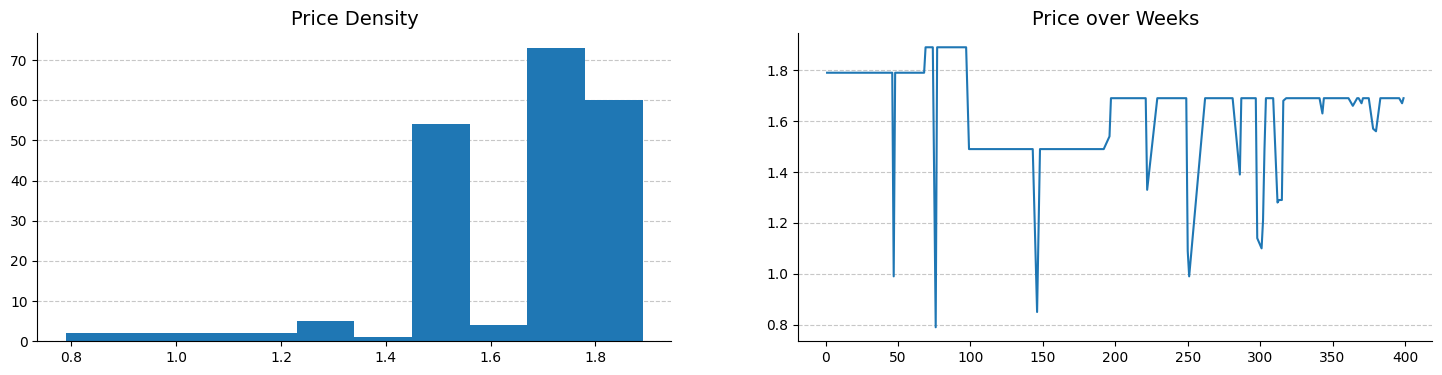

[1.79 0.99 1.89 0.79 1.49 0.85 1.54 1.69 1.33 1.09 1.39 1.14 1.1  1.21
 1.28 1.29 1.68 1.63 1.66 1.67 1.57 1.56]
Median Price: 1.69
Mean Price: 1.6369756097560972
STD Price: 0.1896996969287829


In [198]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, nrows = 1, figsize = (18, 4))
ax1.hist(data_modelling.PRICE)
ax1.set_title('Price Density', fontsize = 14)

ax2.plot(data_modelling.WEEK, data_modelling.PRICE)
ax2.set_title('Price over Weeks', fontsize = 14)
plt.show()

print(data_modelling.PRICE.unique())
print(f'Median Price: {np.median(data_modelling.PRICE)}')
print(f'Mean Price: {np.mean(data_modelling.PRICE)}')
print(f'STD Price: {np.std(data_modelling.PRICE)}')

### 3.2 Check Price Outliers 

Upper: 2.24
Lower: 1.04


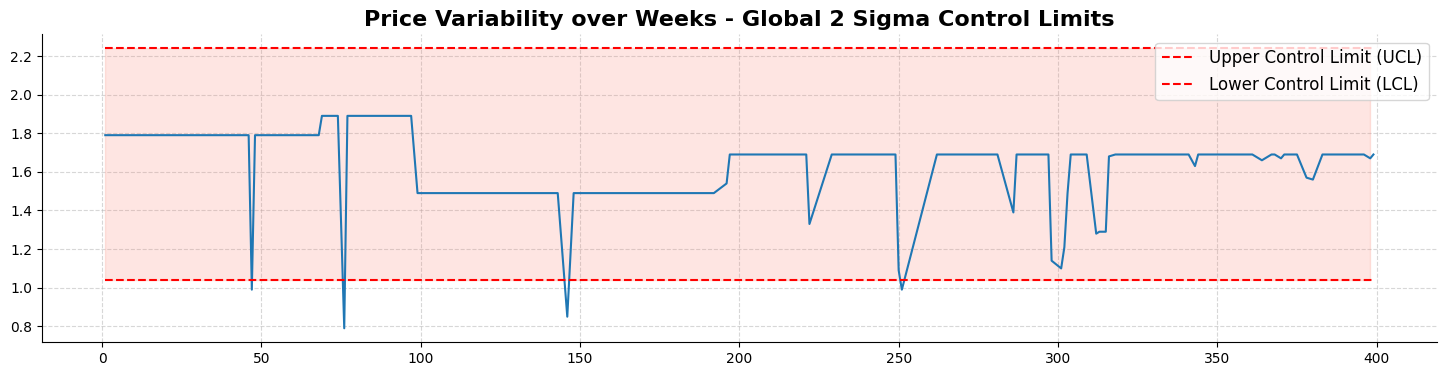

In [199]:
lower_price, upper_price = iqr(column = 'PRICE', k = 1.5)

plt.figure(figsize = (18, 4))
plt.plot(data_modelling.WEEK, data_modelling.PRICE)
plt.hlines(y = upper_price, xmin = np.min(data_modelling.WEEK), xmax = np.max(data_modelling.WEEK), linestyles = '--', colors = 'red', label = 'Upper Control Limit (UCL)')
plt.hlines(y = lower_price, xmin = np.min(data_modelling.WEEK), xmax = np.max(data_modelling.WEEK), linestyles = '--', colors = 'red', label = 'Lower Control Limit (LCL)')
plt.title('Price Variability over Weeks - Global 2 Sigma Control Limits', fontsize = 16, fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, ls = '--', alpha = 0.5)
plt.fill_between(x = range(np.min(data_modelling.WEEK), np.max(data_modelling.WEEK)), y1 = lower_price, y2 = upper_price, color = 'salmon', alpha = 0.2)
plt.legend(fontsize = 12, loc = 'upper right')
plt.show()

In [200]:
# Dropping higthers points
data_modelling['PRICE'] = data_modelling['PRICE'].where(data_modelling['PRICE'] > lower_price)

# Interpolate
data_modelling['PRICE'] = data_modelling.PRICE.interpolate(method = 'linear')
data_modelling.head(3)

,WEEK,PRICE,MOVE
0,1,1.79,50.0
1,2,1.79,32.0
2,3,1.79,48.0


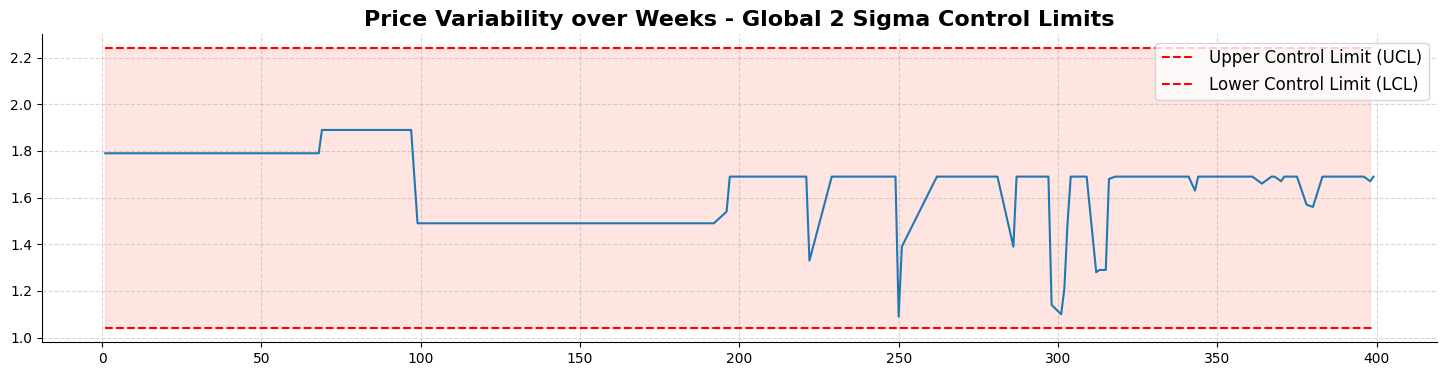

In [201]:
plt.figure(figsize = (18, 4))
plt.plot(data_modelling.WEEK, data_modelling.PRICE)
plt.hlines(y = upper_price, xmin = np.min(data_modelling.WEEK), xmax = np.max(data_modelling.WEEK), linestyles = '--', colors = 'red', label = 'Upper Control Limit (UCL)')
plt.hlines(y = lower_price, xmin = np.min(data_modelling.WEEK), xmax = np.max(data_modelling.WEEK), linestyles = '--', colors = 'red', label = 'Lower Control Limit (LCL)')
plt.title('Price Variability over Weeks - Global 2 Sigma Control Limits', fontsize = 16, fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, ls = '--', alpha = 0.5)
plt.fill_between(x = range(np.min(data_modelling.WEEK), np.max(data_modelling.WEEK)), y1 = lower_price, y2 = upper_price, color = 'salmon', alpha = 0.2)
plt.legend(fontsize = 12, loc = 'upper right')
plt.show()

### 3.3 Build Baseline using by checking differents Methods

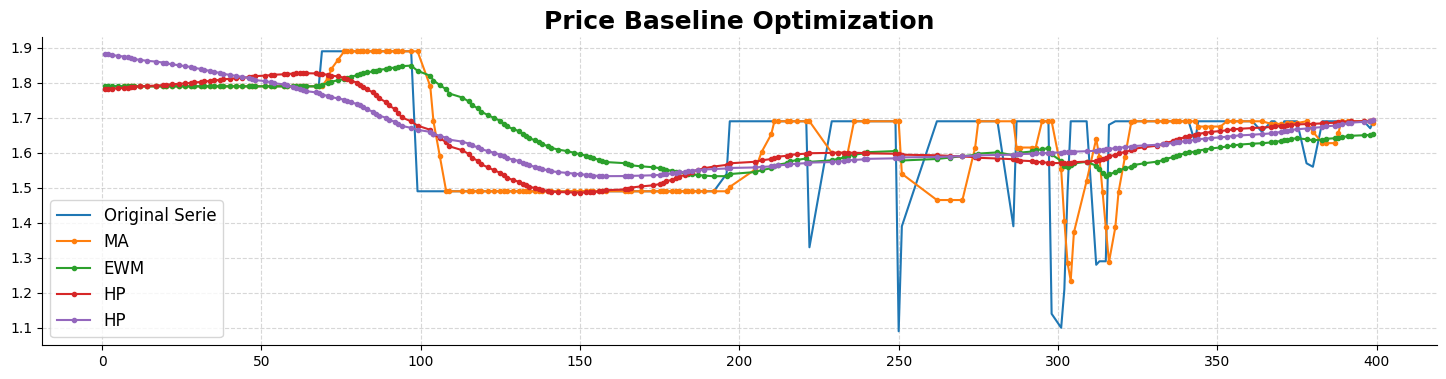

In [205]:
WINDOW_SIZE_PRICE = 4
mooving_avg_price = mooving_average(series = data_modelling['PRICE'], window_size = WINDOW_SIZE_PRICE)

# HP 
cycle_price, trend_hp_price = hpfilter(x = data_modelling['PRICE'], lamb = 14400)

# STL
stl_price = STL(endog = data_modelling.PRICE, period = 52).fit()
trend_stl_price = stl_price.trend

plt.figure(figsize = (18, 4))
plt.plot(data_modelling.WEEK, data_modelling.PRICE, label = 'Original Serie')
plt.plot(data_modelling.WEEK[WINDOW_SIZE_PRICE:], mooving_avg_price, label = 'MA', marker = '.')
plt.plot(data_modelling.WEEK, data_modelling.PRICE.ewm(span = 52).mean(), label = 'EWM', marker = '.')
plt.plot(data_modelling.WEEK, trend_hp_price, label = 'HP', marker = '.')
plt.plot(data_modelling.WEEK, trend_stl_price, label = 'HP', marker = '.')
plt.title('Price Baseline Optimization', fontsize = 18, fontweight = 'bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, ls = '--', alpha = 0.5)
plt.legend(fontsize = 12)
plt.show()

### 3.4 Checking Lower MAE

In [203]:
# MAE 
mae_ewm_price = (data_modelling['PRICE'] - data_modelling.PRICE.ewm(span = 52).mean()).abs().mean()
mae_stl_price = (data_modelling['PRICE'] - trend_stl_price).abs().mean()
mae_hp_price  = (data_modelling['PRICE'] - trend_hp_price).abs().mean()

print(f"MAE EWM (Exponentially Weighted Moving Average) : {mae_ewm_price:.4f}")
print(f"MAE STL (LOESS)              : {mae_stl_price:.4f}")
print(f"MAE HP  (Hodrick-Prescott)   : {mae_hp_price:.4f}")

MAE EWM (Exponentially Weighted Moving Average) : 0.0940
MAE STL (LOESS)              : 0.0914
MAE HP  (Hodrick-Prescott)   : 0.0698


## 4.

In [ ]:
# Adding the choisen baseline for Sales
data_modelling['HP_baseline_Sales'] = trend_hp

# Adding the choisen baseline for Price
data_modelling['HP_baseline_Price'] = trend_hp_price

# Price uplift Ratio ?
data_modelling['Sales_ratio'] = np.round((data_modelling.MOVE / trend_hp) * 100, 2)

data_modelling.head()

,WEEK,PRICE,MOVE,HP_baseline_Sales,HP_baseline_Price,Sales_ratio
0,1,1.79,50.0,54.565112,1.780932,91.63
1,2,1.79,32.0,54.757701,1.782015,58.44
2,3,1.79,48.0,54.949973,1.783099,87.35
3,5,1.79,39.0,55.140031,1.784185,70.73
4,7,1.79,52.0,55.325494,1.785275,93.99
